In [3]:
import numpy as np            # For numerical operations and handling arrays
import pandas as pd           # For data manipulation and creating DataFrames
import seaborn as sns         # High-level interface for drawing statistical graphics
import matplotlib.pyplot as plt
import warnings               # To handle library-specific warnings
warnings.filterwarnings("ignore") # Suppress warnings to keep the output clean and readable

# --- Scikit-Learn Modules ---

# Splitting data into Training (to learn) and Testing (to validate) sets
from sklearn.model_selection import train_test_split

# Tool to apply different preprocessing steps to different columns simultaneously
from sklearn.compose import ColumnTransformer

# OneHotEncoder: Converts categories (text) to numbers (0s and 1s)
# StandardScaler: Scales numbers so they have a mean of 0 and variance of 1
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Pipeline: A 'container' that chains together preprocessing and the model
from sklearn.pipeline import Pipeline

# The algorithm we are using for prediction (Linear Regression)
from sklearn.linear_model import LinearRegression

# Evaluation Metrics: To check how 'wrong' or 'right' our model is
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load the dataset from a CSV file into a pandas DataFrame named 'df'
df = pd.read_csv("House_Rent_Dataset.csv")

In [5]:
df #displays the entire table

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


In [6]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [7]:
df.tail()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent
4745,2022-05-04,2,15000,1000,4 out of 5,Carpet Area,Suchitra Circle,Hyderabad,Unfurnished,Bachelors,2,Contact Owner


In [8]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [ ]:
df.describe()

In [8]:
df.info

<bound method DataFrame.info of        Posted On  BHK   Rent  Size            Floor    Area Type  \
0     2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1     2022-05-13    2  20000   800       1 out of 3   Super Area   
2     2022-05-16    2  17000  1000       1 out of 3   Super Area   
3     2022-07-04    2  10000   800       1 out of 2   Super Area   
4     2022-05-09    2   7500   850       1 out of 2  Carpet Area   
...          ...  ...    ...   ...              ...          ...   
4741  2022-05-18    2  15000  1000       3 out of 5  Carpet Area   
4742  2022-05-15    3  29000  2000       1 out of 4   Super Area   
4743  2022-07-10    3  35000  1750       3 out of 5  Carpet Area   
4744  2022-07-06    3  45000  1500     23 out of 34  Carpet Area   
4745  2022-05-04    2  15000  1000       4 out of 5  Carpet Area   

                 Area Locality       City Furnishing Status  Tenant Preferred  \
0                       Bandel    Kolkata       Unfurnished  Bachelors

In [9]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [10]:
df.columns


Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [11]:
# numeric columns

numeric_columns = df[['Posted On','BHK','Rent','Size','Bathroom']]

In [12]:
numeric_columns

,Posted On,BHK,Rent,Size,Bathroom
0,2022-05-18,2,10000,1100,2
1,2022-05-13,2,20000,800,1
2,2022-05-16,2,17000,1000,1
3,2022-07-04,2,10000,800,1
4,2022-05-09,2,7500,850,1
...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,2
4742,2022-05-15,3,29000,2000,3
4743,2022-07-10,3,35000,1750,3
4744,2022-07-06,3,45000,1500,2


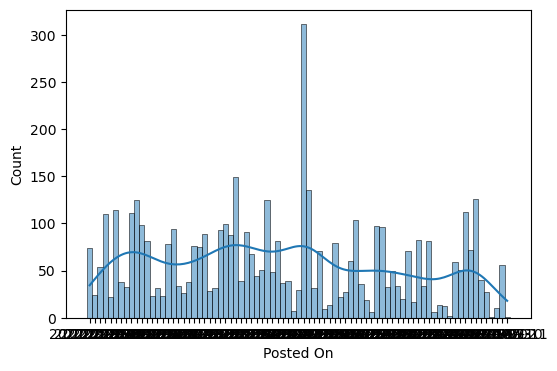

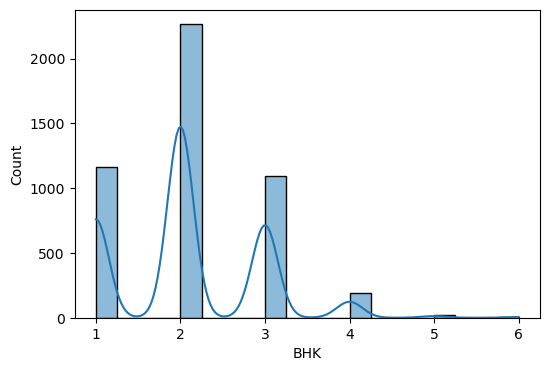

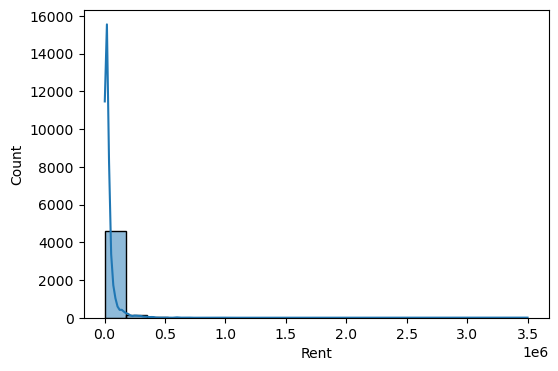

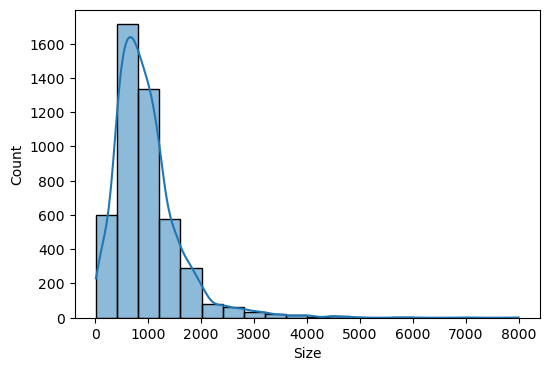

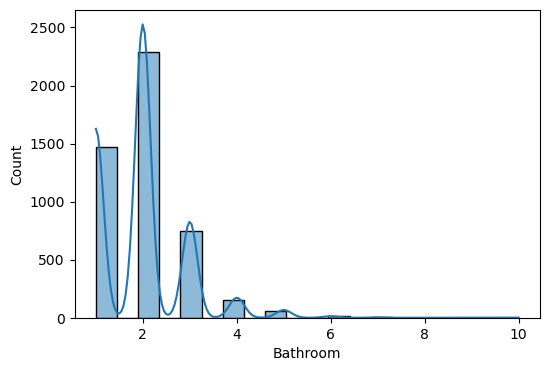

In [13]:
# create visulization

numeric_columns = ['Posted On','BHK','Rent','Size','Bathroom']
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.histplot(df[col],kde=True, bins = 20)

# KDE = Line on the bars
# bins = Count of bars

<Axes: xlabel='Bathroom', ylabel='count'>

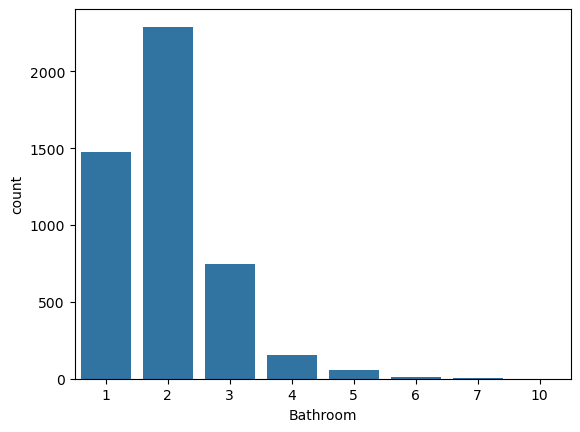

In [14]:
# single columns

sns.countplot(x = df['Bathroom'])

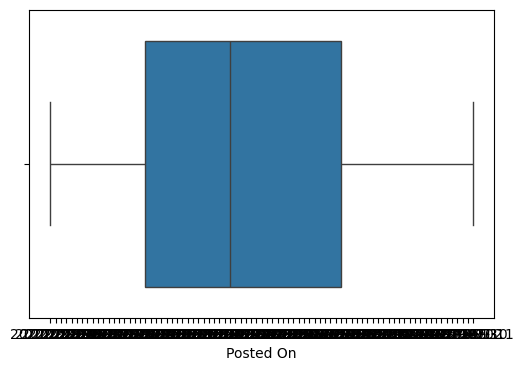

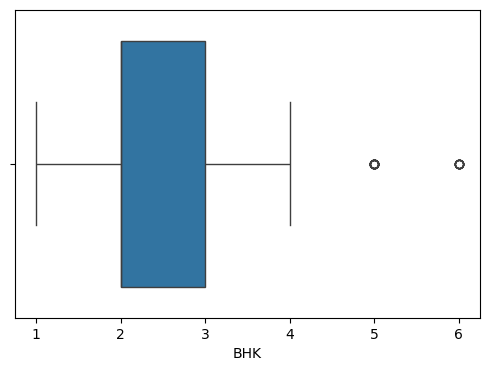

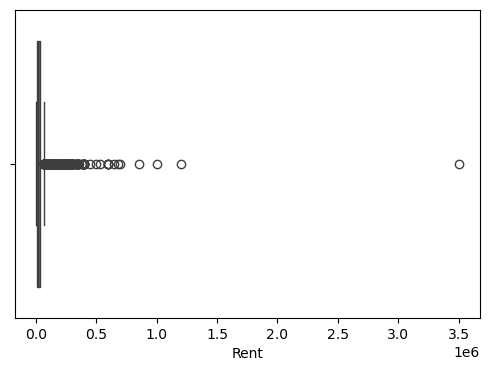

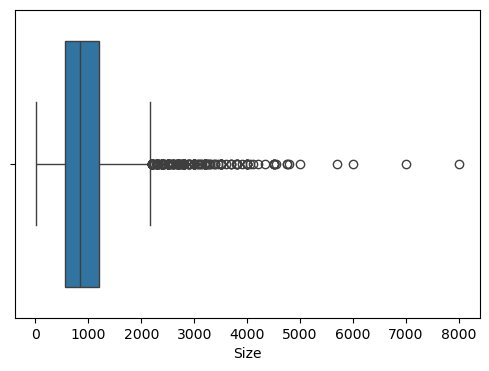

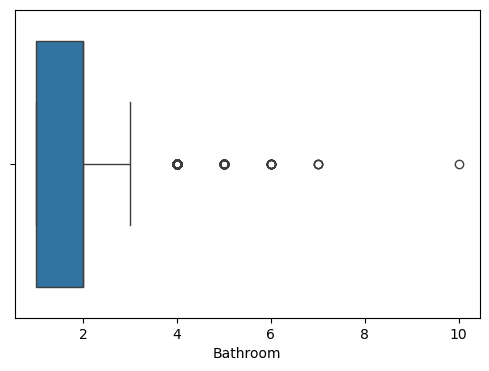

In [15]:
#Box Plot
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.boxplot(x = df[col])

In [16]:
#copy the data 
df_cleaned = df.copy()

In [17]:
df_cleaned

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


In [9]:
#X =>inputs and y=>target
# X contains all columns EXCEPT 'Rent' (these are your independent variables/features)
X = df.drop("Rent", axis=1)

# y contains ONLY the 'Rent' column (this is your dependent variable/target)
Y = df["Rent"]

In [19]:
# List the columns that contain numbers
numeric_data = ['BHK', 'Size', 'Bathroom']

# List the columns that contain text/categories
category_data = ['Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Floor']

# Reorganize X to only include these specific features in the given order
X = X[numeric_data + category_data]

In [20]:
# Splitting the data: 75% for training the model, 25% for testing its accuracy
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42
)

In [21]:
# 1. Define the transformers
preprocessor = ColumnTransformer(
    transformers=[
        # (Name, Transformer, Columns to apply it to)
        ('num', StandardScaler(), numeric_data),           # Standardization for numbers
        ('cat', OneHotEncoder(handle_unknown='ignore'), category_data)    # One-Hot Encoding for text
    ]
)

In [22]:
# Building the 'conveyor belt'
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),      # Step 1: Clean and scale the data
    ('regressor', LinearRegression())    # Step 2: Run the model
])

In [23]:
# Now you can train the WHOLE thing with one line
#training model
model_pipeline.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
# Use the entire pipeline to transform the test data and generate rent predictions
Y_pred = model_pipeline.predict(X_test)

In [25]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

# Print the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE): ",mse)
print("R2 Score:",r2)

Mean Absolute Error (MAE): 26675.64504077797
Mean Squared Error (MSE):  4973402077.0350065
R2 Score: -0.30721172872287017


In [26]:
new_house_data = pd.DataFrame([[2, 1100, 2, 'AArea', 'Nehrunagar', 'Mumbai', 'Semi-Furnished', '2 out of 5']],columns=numeric_data + category_data)
new_prediction = model_pipeline.predict(new_house_data)
print("Predicted Rent for this house:",new_prediction)

Predicted Rent for this house: [92300.41677935]


In [27]:
# Define the new house data with actual values
# Based on: ['BHK', 'Size', 'Bathroom', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Floor']
new_house_data = pd.DataFrame([[2, 1100, 2, 'Super Area', 'Bandra West', 'Mumbai', 'Semi-Furnished', '2 out of 5']], 
                              columns=numeric_data + category_data)

# Predict using the pipeline we built
new_prediction = model_pipeline.predict(new_house_data)

print(f"Predicted Rent for this house: ₹{new_prediction[0]:.2f}")

Predicted Rent for this house: ₹159381.45


In [30]:
new_house_data = pd.DataFrame([{
    "BHK":2,
    "Bathroom":2,
    "Size":1000,
    "Area Type":"Super Area",
    "Area Locality":"bhopal",
    "City": "Kolkata",
    "Furnishing Status": "Semi-Furnished", # Fixed name
    "Floor": "2 out of 5"                  # Added missing column
}])
new_prediction = model_pipeline.predict(new_house_data)
print("New Rent:",new_prediction)

New Rent: [18493.39969816]
